# UCI Human Activity Recognition EDA — Deep Neural Networks

**Dataset:** UCI HAR (Anguita et al., 2013)  
**Source:** Smartphone accelerometer + gyroscope (Samsung Galaxy S II, 30 volunteers)  
**Samples:** 10,299 | **Features:** 561 (time + frequency domain) | **Target:** 6 activity classes  
**Task:** Classify human activities from inertial sensor data — first neural network in the project

## Purpose
Inspect raw data before preprocessing:
- Verify the pre-computed feature distributions and scales
- Quantify class balance across 6 activities
- Analyze feature groups (time vs frequency, accelerometer vs gyroscope)
- Assess feature redundancy and correlation (561 features — high dimensionality)
- Evaluate subject-wise train/test split quality
- Every finding maps to a specific preprocessing decision

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
import urllib.request
import os

# Configuration
RAW_DIR = Path('../data/raw')
HAR_URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
HAR_ZIP = RAW_DIR / 'har.zip'
HAR_DIR = RAW_DIR / 'UCI HAR Dataset'
EDA_DIR = RAW_DIR / 'eda_DNN'
EDA_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 113

# Download and extract if not present
if not HAR_DIR.exists():
    print("Downloading UCI HAR dataset...")
    resp = requests.get(HAR_URL)
    HAR_ZIP.write_bytes(resp.content)
    print(f"    Saved zip to: {HAR_ZIP}")

    # Outer zip contains 'UCI HAR Dataset.zip' — need to extract twice
    with zipfile.ZipFile(HAR_ZIP, 'r') as z:
        z.extractall(RAW_DIR)
    print(f"    Extracted outer zip to: {RAW_DIR}")

    # Check if inner zip exists
    inner_zip = RAW_DIR / 'UCI HAR Dataset.zip'
    if inner_zip.exists():
        with zipfile.ZipFile(inner_zip, 'r') as z:
            z.extractall(RAW_DIR)
        print(f"    Extracted inner zip to: {RAW_DIR}")

    print(f"    Final dataset dir: {HAR_DIR}")
else:
    print(f"Dataset already exists: {HAR_DIR}")

# Load feature names and activity labels
feature_names_raw = pd.read_csv(
    HAR_DIR / 'features.txt', sep=r'\s+', header=None, names=['idx', 'name']
)['name'].tolist()

# Deduplicate — UCI HAR has repeated feature names (e.g. bandsEnergy)
counts = {}
feature_names = []
for name in feature_names_raw:
    if name in counts:
        counts[name] += 1
        feature_names.append(f"{name}_{counts[name]}")
    else:
        counts[name] = 0
        feature_names.append(name)

activity_labels = pd.read_csv(
    HAR_DIR / 'activity_labels.txt', sep=r'\s+', header=None, names=['id', 'activity']
)
ACTIVITY_NAMES = activity_labels['activity'].tolist()

# Load train/test data (pre-split by subject)
X_train = pd.read_csv(HAR_DIR / 'train' / 'X_train.txt', sep=r'\s+', header=None, names=feature_names)
y_train = pd.read_csv(HAR_DIR / 'train' / 'y_train.txt', header=None, names=['activity']
)['activity'].values
subject_train = pd.read_csv(HAR_DIR / 'train' / 'subject_train.txt', header=None, names=['subject']
)['subject'].values

X_test = pd.read_csv(HAR_DIR / 'test' / 'X_test.txt', sep=r'\s+', header=None, names=feature_names)
y_test = pd.read_csv(HAR_DIR / 'test' / 'y_test.txt', header=None, names=['activity']
)['activity'].values
subject_test = pd.read_csv(HAR_DIR / 'test' / 'subject_test.txt', header=None, names=['subject']
)['subject'].values

print("=" * 60)
print("UCI HAR — Raw Data Summary")
print("=" * 60)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Labels — Train: {y_train.shape} | Test: {y_test.shape}")
print(f"Total samples: {len(X_train) + len(X_test):,}")
print(f"Features: {X_train.shape[1]}")
print(f"Dtypes: {X_train.dtypes.unique()}")
print(f"Activities ({len(ACTIVITY_NAMES)}): {', '.join(ACTIVITY_NAMES)}")
print(f"Label range: [{y_train.min()}, {y_train.max()}] (1-indexed)") # type: ignore
print(f"Subjects — Train: {np.unique(subject_train)} ({len(np.unique(subject_train))} subjects)") # type: ignore
print(f"Subjects — Test: {np.unique(subject_test)} ({len(np.unique(subject_test))} subjects)") # type: ignore

Dataset already exists: ..\data\raw\UCI HAR Dataset
UCI HAR — Raw Data Summary
Train: (7352, 561) | Test: (2947, 561)
Labels — Train: (7352,) | Test: (2947,)
Total samples: 10,299
Features: 561
Dtypes: [dtype('float64')]
Activities (6): WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING
Label range: [1, 6] (1-indexed)
Subjects — Train: [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30] (21 subjects)
Subjects — Test: [ 2  4  9 10 12 13 18 20 24] (9 subjects)


In [2]:
# Step 1: Missing values and duplicates
print("=" * 60)
print("[1/9] MISSING VALUES & DUPLICATES")
print("=" * 60)

# NaN check across both sets
train_nan = X_train.isnull().sum().sum()
test_nan = X_test.isnull().sum().sum()
print(f"\nTrain NaN: {train_nan}")
print(f"Test NaN:  {test_nan}")

# Duplicates within each set
train_dups = X_train.duplicated().sum()
test_dups = X_test.duplicated().sum()
print(f"\nTrain duplicates: {train_dups} ({train_dups / len(X_train) * 100:.2f}%)")
print(f"Test duplicates:  {test_dups} ({test_dups / len(X_test) * 100:.2f}%)")

# Check for cross-set leakage (same feature vector in both train and test)
# This would violate the subject-wise split
X_train_set = set(map(tuple, X_train.values))
X_test_set = set(map(tuple, X_test.values))
overlap = len(X_train_set & X_test_set)
print(f"\nCross-set overlap (same row in train AND test): {overlap}")
if overlap == 0:
    print("    No data leakage — subject-wise split is clean")
else:
    print(f"    WARNING: {overlap} shared rows — investigate")

# Inf check
train_inf = np.isinf(X_train.values).sum()
test_inf = np.isinf(X_test.values).sum()
print(f"\nTrain Inf: {train_inf}")
print(f"Test Inf:  {test_inf}")

[1/9] MISSING VALUES & DUPLICATES

Train NaN: 0
Test NaN:  0

Train duplicates: 0 (0.00%)
Test duplicates:  0 (0.00%)

Cross-set overlap (same row in train AND test): 0
    No data leakage — subject-wise split is clean

Train Inf: 0
Test Inf:  0


[2/9] CLASS DISTRIBUTION


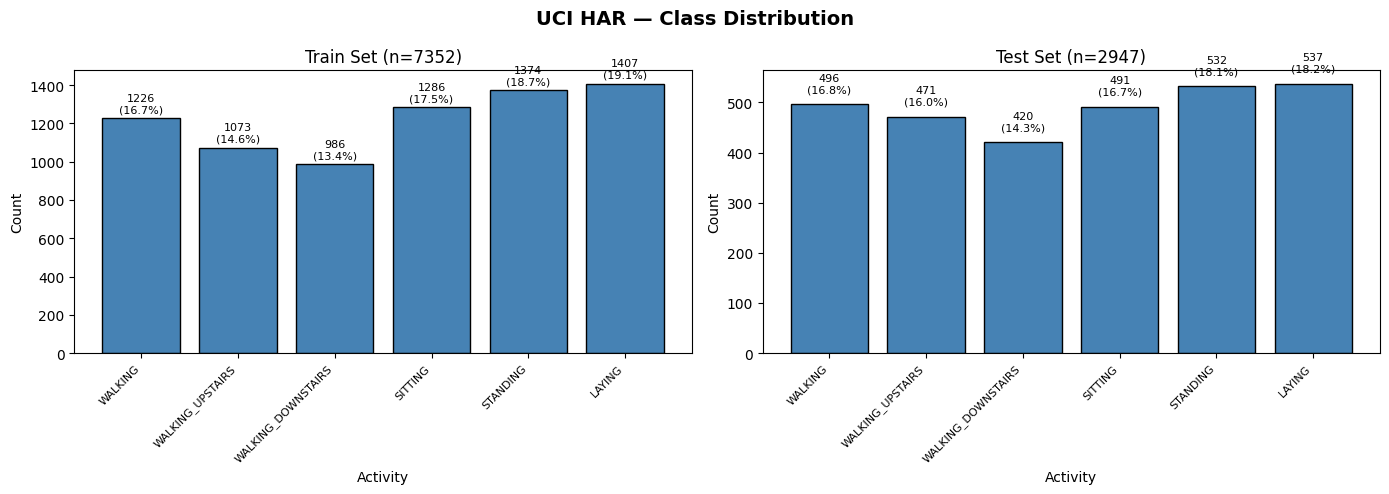


Train — min: 986 | max: 1407 | ratio: 1.43x
Test  — min: 420 | max: 537 | ratio: 1.28x


In [3]:
# Step 2: Class distribution across train/test
print("=" * 60)
print("[2/9] CLASS DISTRIBUTION")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in [(axes[0], y_train, 'Train'), (axes[1], y_test, 'Test')]:
    unique, counts = np.unique(labels, return_counts=True) # type: ignore
    bars = ax.bar(unique, counts, color='steelblue', edgecolor='black')
    ax.set_xlabel('Activity')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} Set (n={len(labels)})')
    ax.set_xticks(unique)
    ax.set_xticklabels(ACTIVITY_NAMES, rotation=45, ha='right', fontsize=8)

    # Annotate bars with count + percentage
    for bar, count in zip(bars, counts):
        pct = count / len(labels) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

plt.suptitle('UCI HAR — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratio
train_counts = np.bincount(y_train)[1:]  # skip index 0 (labels are 1-indexed) 
test_counts = np.bincount(y_test)[1:]
print(f"\nTrain — min: {train_counts.min()} | max: {train_counts.max()} | ratio: {train_counts.max() / train_counts.min():.2f}x")
print(f"Test  — min: {test_counts.min()} | max: {test_counts.max()} | ratio: {test_counts.max() / test_counts.min():.2f}x")

[3/9] FEATURE STATISTICS

Global min: -1.000000
Global max: 1.000000

Per-feature means  — min: -0.9841 | max: 0.8304 | median: -0.6595
Per-feature stds   — min: 0.0408 | max: 0.7517 | median: 0.2654
Per-feature mins   — min: -1.0000 | max: -0.4939
Per-feature maxs   — min: 0.4652 | max: 1.0000

Features strictly in [-1, 1]: 561 / 561


C:\Users\Max\AppData\Local\Temp\ipykernel_31568\2541767296.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


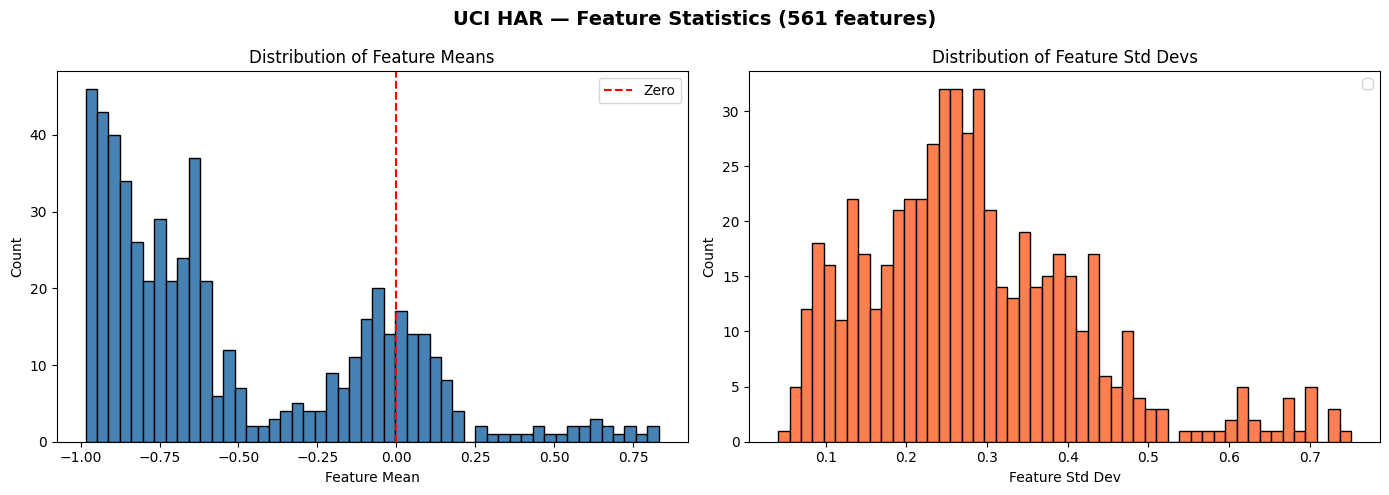

In [4]:
# Step 3: Feature statistics — range, scale, and normalization check
print("=" * 60)
print("[3/9] FEATURE STATISTICS")
print("=" * 60)

# UCI HAR features are already normalized to [-1, 1] per the dataset docs
# Let's verify this claim
train_min = X_train.min().min()
train_max = X_train.max().max()
print(f"\nGlobal min: {train_min:.6f}")
print(f"Global max: {train_max:.6f}")

# Per-feature stats
feat_means = X_train.mean()
feat_stds = X_train.std()
feat_mins = X_train.min()
feat_maxs = X_train.max()

print(f"\nPer-feature means  — min: {feat_means.min():.4f} | max: {feat_means.max():.4f} | median: {feat_means.median():.4f}")
print(f"Per-feature stds   — min: {feat_stds.min():.4f} | max: {feat_stds.max():.4f} | median: {feat_stds.median():.4f}")
print(f"Per-feature mins   — min: {feat_mins.min():.4f} | max: {feat_mins.max():.4f}")
print(f"Per-feature maxs   — min: {feat_maxs.min():.4f} | max: {feat_maxs.max():.4f}")

# How many features are truly in [-1, 1]?
in_range = ((feat_mins >= -1.0) & (feat_maxs <= 1.0)).sum()
print(f"\nFeatures strictly in [-1, 1]: {in_range} / {X_train.shape[1]}")

# Visualize feature mean and std distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(feat_means, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Feature Mean')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Feature Means')
axes[0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0].legend()

axes[1].hist(feat_stds, bins=50, color='coral', edgecolor='black')
axes[1].set_xlabel('Feature Std Dev')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Feature Std Devs')
axes[1].legend()

plt.suptitle('UCI HAR — Feature Statistics (561 features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR / 'feature_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

[4/9] CORRELATION STRUCTURE

Highly correlated pairs (|r| > 0.9): 8206 / 157080 (5.2%)
Moderately correlated pairs (|r| > 0.7): 36564 / 157080 (23.3%)


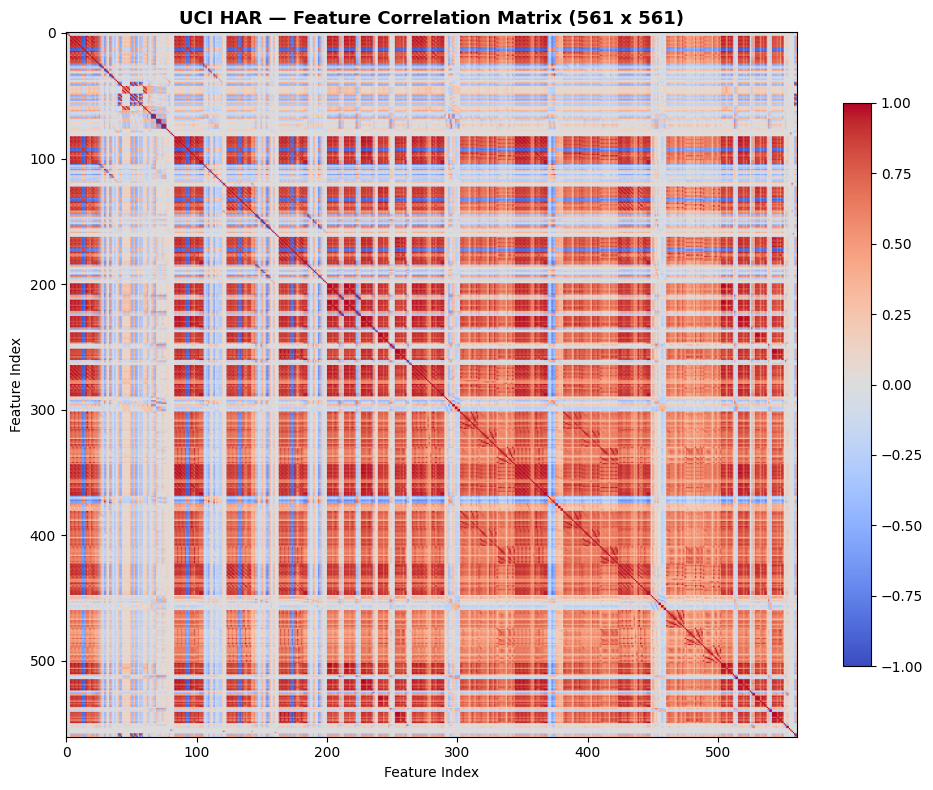

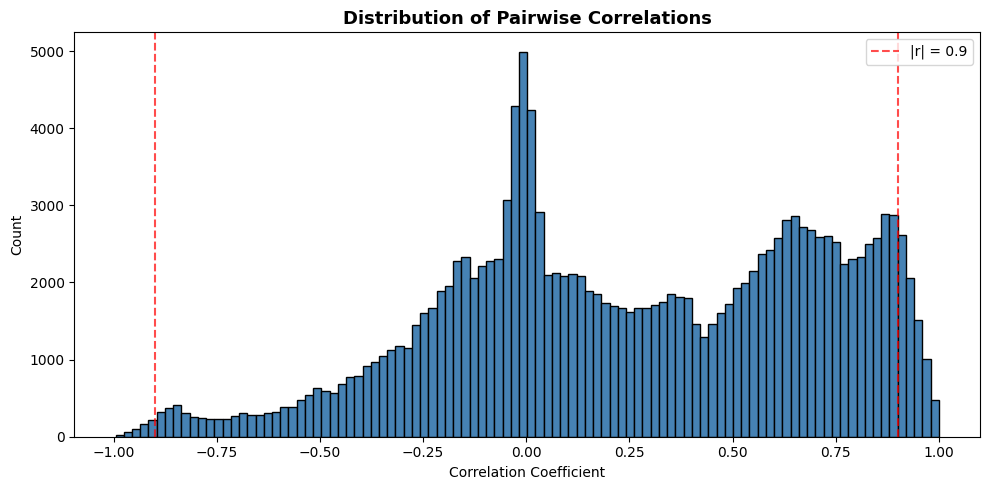

In [5]:
# Step 4: Correlation structure — high-dimensional feature redundancy
print("=" * 60)
print("[4/9] CORRELATION STRUCTURE")
print("=" * 60)

# Full correlation matrix
corr = X_train.corr()

# Count highly correlated pairs (|r| > 0.9)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = (upper.abs() > 0.9).sum().sum()
total_pairs = X_train.shape[1] * (X_train.shape[1] - 1) // 2
print(f"\nHighly correlated pairs (|r| > 0.9): {high_corr} / {total_pairs} ({high_corr / total_pairs * 100:.1f}%)")

# Also check moderate correlation
mod_corr = (upper.abs() > 0.7).sum().sum()
print(f"Moderately correlated pairs (|r| > 0.7): {mod_corr} / {total_pairs} ({mod_corr / total_pairs * 100:.1f}%)")

# Heatmap of full correlation matrix (561x561)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_title('UCI HAR — Feature Correlation Matrix (561 x 561)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Index')
ax.set_ylabel('Feature Index')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(EDA_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution of correlation values
fig, ax = plt.subplots(figsize=(10, 5))
corr_vals = upper.values.flatten()
corr_vals = corr_vals[~np.isnan(corr_vals)]
ax.hist(corr_vals, bins=100, color='steelblue', edgecolor='black')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pairwise Correlations', fontsize=13, fontweight='bold')
ax.axvline(0.9, color='red', linestyle='--', alpha=0.7, label='|r| = 0.9')
ax.axvline(-0.9, color='red', linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.savefig(EDA_DIR / 'correlation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

[5/9] FEATURE VARIANCE

Near-zero variance features (std < 0.05): 1 / 561

Variance — min: 0.001665 | max: 0.565102 | median: 0.070455
Std Dev  — min: 0.040811 | max: 0.751733 | median: 0.265434

Top 10 highest-variance features:
    fBodyAccJerk-entropy()-X                      var=0.5651  std=0.7517
    fBodyAccJerk-entropy()-Y                      var=0.5425  std=0.7365
    tBodyAccJerkMag-entropy()                     var=0.5289  std=0.7273
    fBodyAcc-entropy()-X                          var=0.5257  std=0.7251
    tGravityAcc-correlation()-X,Z                 var=0.5009  std=0.7077
    tGravityAcc-correlation()-Y,Z                 var=0.4958  std=0.7042
    tBodyGyroJerkMag-entropy()                    var=0.4952  std=0.7037
    tGravityAcc-energy()-X                        var=0.4871  std=0.6979
    tGravityAcc-correlation()-X,Y                 var=0.4853  std=0.6966
    fBodyAccMag-entropy()                         var=0.4661  std=0.6827

Bottom 10 lowest-variance features:
   

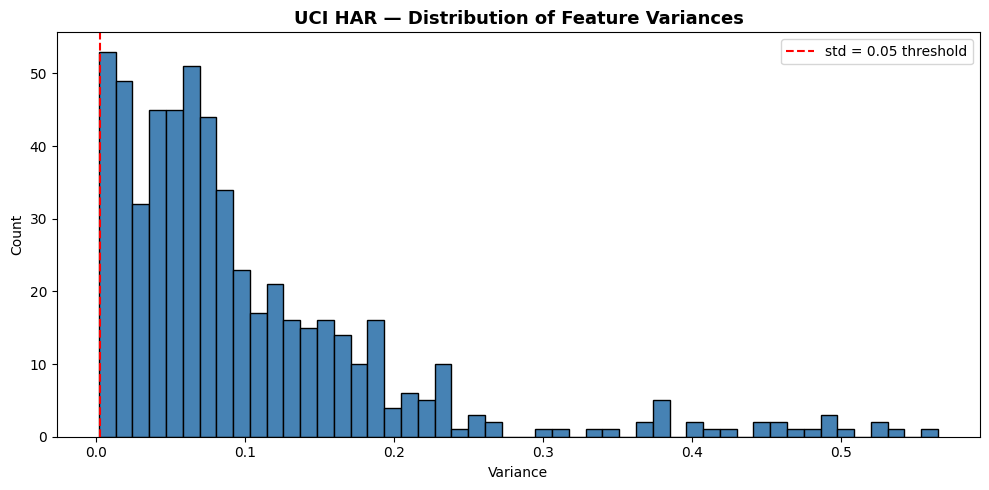

In [6]:
# Step 5: Feature variance — identify low-information features
print("=" * 60)
print("[5/9] FEATURE VARIANCE")
print("=" * 60)

variances = X_train.var()

# Near-zero variance features (std < 0.05)
low_var = (variances < 0.05**2).sum()
print(f"\nNear-zero variance features (std < 0.05): {low_var} / {X_train.shape[1]}")

# Variance distribution
print(f"\nVariance — min: {variances.min():.6f} | max: {variances.max():.6f} | median: {variances.median():.6f}")
print(f"Std Dev  — min: {np.sqrt(variances.min()):.6f} | max: {np.sqrt(variances.max()):.6f} | median: {np.sqrt(variances.median()):.6f}")

# Top 10 highest variance features
top_var = variances.nlargest(10)
print(f"\nTop 10 highest-variance features:")
for name, v in top_var.items():
    print(f"    {name:45s} var={v:.4f}  std={np.sqrt(v):.4f}")

# Bottom 10 lowest variance features
bot_var = variances.nsmallest(10)
print(f"\nBottom 10 lowest-variance features:")
for name, v in bot_var.items():
    print(f"    {name:45s} var={v:.6f}  std={np.sqrt(v):.6f}")

# Histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(variances, bins=50, color='steelblue', edgecolor='black')
ax.set_xlabel('Variance')
ax.set_ylabel('Count')
ax.set_title('UCI HAR — Distribution of Feature Variances', fontsize=13, fontweight='bold')
ax.axvline(0.05**2, color='red', linestyle='--', label='std = 0.05 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(EDA_DIR / 'feature_variance.png', dpi=150, bbox_inches='tight')
plt.show()

[6/9] PER-CLASS FEATURE PROFILES

Top 15 most discriminative features (highest between-class variance):
    fBodyAccJerk-entropy()-X                      between-class var=0.6650
    fBodyAccJerk-entropy()-Y                      between-class var=0.6270
    tBodyAccJerkMag-entropy()                     between-class var=0.6058
    fBodyAcc-entropy()-X                          between-class var=0.6054
    fBodyAccMag-entropy()                         between-class var=0.5221
    tBodyGyroJerkMag-entropy()                    between-class var=0.5208
    fBodyBodyAccJerkMag-entropy()                 between-class var=0.5185
    fBodyAcc-entropy()-Y                          between-class var=0.4975
    tGravityAcc-energy()-X                        between-class var=0.4958
    tBodyAccJerk-entropy()-X                      between-class var=0.4839
    fBodyAccJerk-entropy()-Z                      between-class var=0.4704
    tBodyAccMag-entropy()                         between-class var=0.4

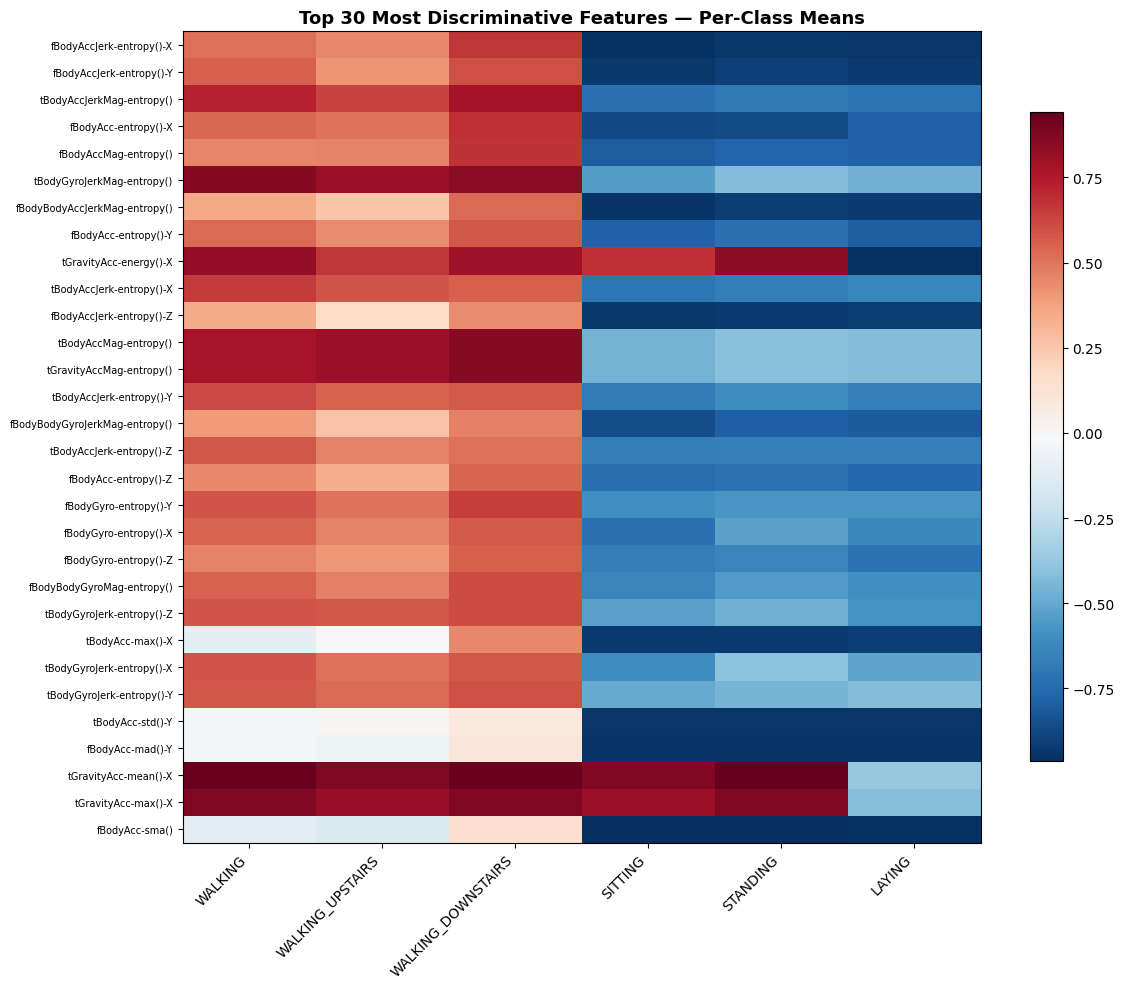


Static (SITTING/STANDING/LAYING) vs Dynamic (WALKING*) — tBodyAcc-mean()-X:
    WALKING                   mean=0.2763
    WALKING_UPSTAIRS          mean=0.2619
    WALKING_DOWNSTAIRS        mean=0.2882
    SITTING                   mean=0.2734
    STANDING                  mean=0.2793
    LAYING                    mean=0.2692


In [7]:
# Step 6: Per-class feature profiles — how separable are activities?
print("=" * 60)
print("[6/9] PER-CLASS FEATURE PROFILES")
print("=" * 60)

# Compute per-class means for all features
class_means = {}
for label, name in zip(range(1, 7), ACTIVITY_NAMES):
    mask = y_train == label
    class_means[name] = X_train[mask].mean()

class_means_df = pd.DataFrame(class_means)

# Find features with highest between-class variance (most discriminative)
between_var = class_means_df.var(axis=1)
top_discrim = between_var.nlargest(15)
print("\nTop 15 most discriminative features (highest between-class variance):")
for name, v in top_discrim.items():
    print(f"    {name:45s} between-class var={v:.4f}")

# Heatmap of top 30 discriminative features across classes
top30_idx = between_var.nlargest(30).index
fig, ax = plt.subplots(figsize=(12, 10))
data = class_means_df.loc[top30_idx]
im = ax.imshow(data.values, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(6))
ax.set_xticklabels(ACTIVITY_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(top30_idx)))
ax.set_yticklabels(top30_idx, fontsize=7)
ax.set_title('Top 30 Most Discriminative Features — Per-Class Means', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(EDA_DIR / 'per_class_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight: static vs dynamic separation
print("\nStatic (SITTING/STANDING/LAYING) vs Dynamic (WALKING*) — tBodyAcc-mean()-X:")
for label, name in zip(range(1, 7), ACTIVITY_NAMES):
    mask = y_train == label
    val = X_train[mask]['tBodyAcc-mean()-X'].mean()
    print(f"    {name:25s} mean={val:.4f}")

[7/9] ACTIVITY SEPARABILITY (t-SNE)

Running t-SNE on train set (7,352 samples, 561 features)...
    Done. Final KL divergence: 1.3716


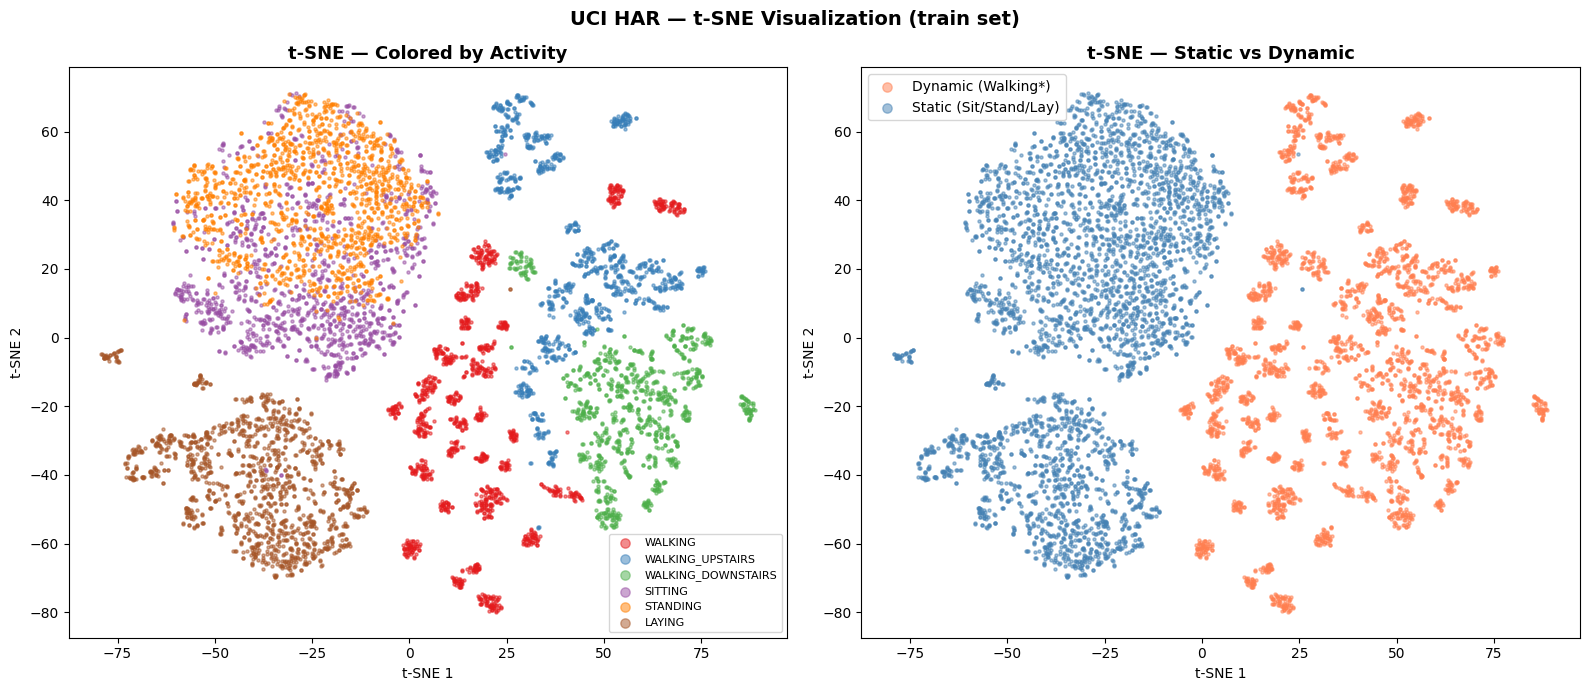

In [8]:
# Step 7: Activity separability — t-SNE visualization
from sklearn.manifold import TSNE

print("=" * 60)
print("[7/9] ACTIVITY SEPARABILITY (t-SNE)")
print("=" * 60)

# t-SNE on train set (subsample for speed — 10K is fine, we have 7352)
print("\nRunning t-SNE on train set (7,352 samples, 561 features)...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_train)
print(f"    Done. Final KL divergence: {tsne.kl_divergence_:.4f}")

# Color map for 6 classes
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by activity
ax = axes[0]
for label, name, color in zip(range(1, 7), ACTIVITY_NAMES, colors):
    mask = y_train == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, label=name,
               s=5, alpha=0.5)
ax.set_title('t-SNE — Colored by Activity', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=8, markerscale=3)

# Right: static vs dynamic grouping
ax = axes[1]
dynamic = np.isin(y_train, [1, 2, 3])  # WALKING, UPSTAIRS, DOWNSTAIRS
static = np.isin(y_train, [4, 5, 6])   # SITTING, STANDING, LAYING
ax.scatter(X_tsne[dynamic, 0], X_tsne[dynamic, 1], c='coral', label='Dynamic (Walking*)',
           s=5, alpha=0.5)
ax.scatter(X_tsne[static, 0], X_tsne[static, 1], c='steelblue', label='Static (Sit/Stand/Lay)',
           s=5, alpha=0.5)
ax.set_title('t-SNE — Static vs Dynamic', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=10, markerscale=3)

plt.suptitle('UCI HAR — t-SNE Visualization (train set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR / 'tsne_separability.png', dpi=150, bbox_inches='tight')
plt.show()

[8/9] SUBJECT VARIABILITY

Train subjects: 21


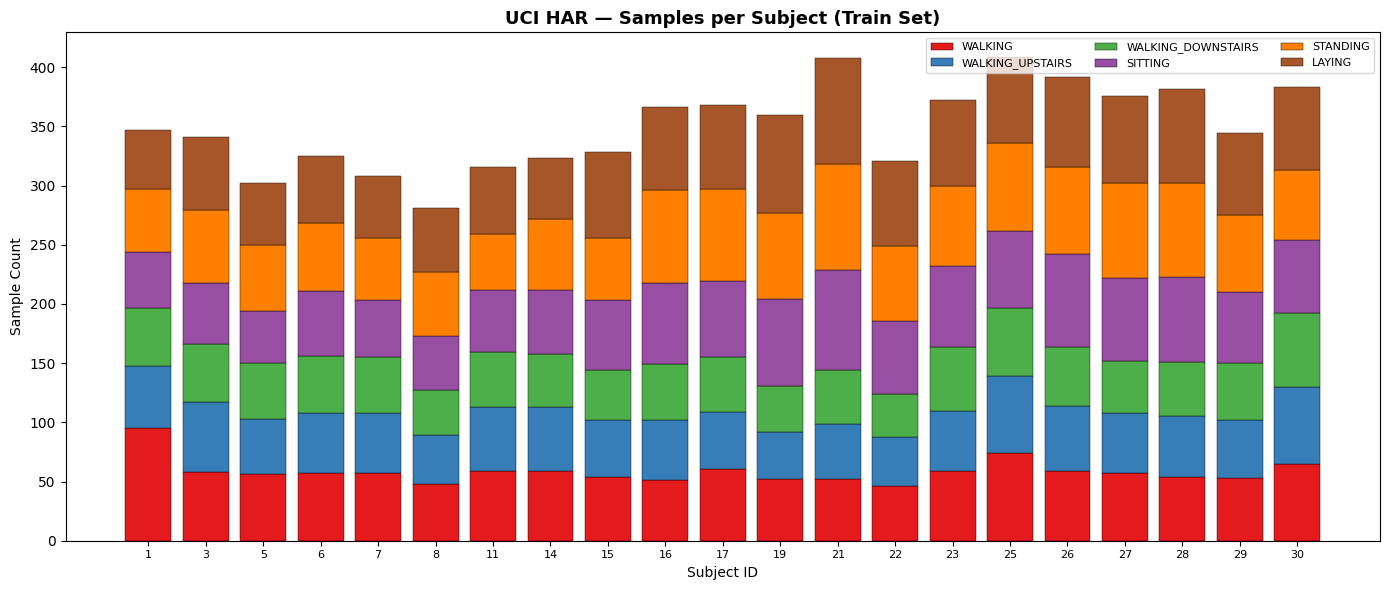

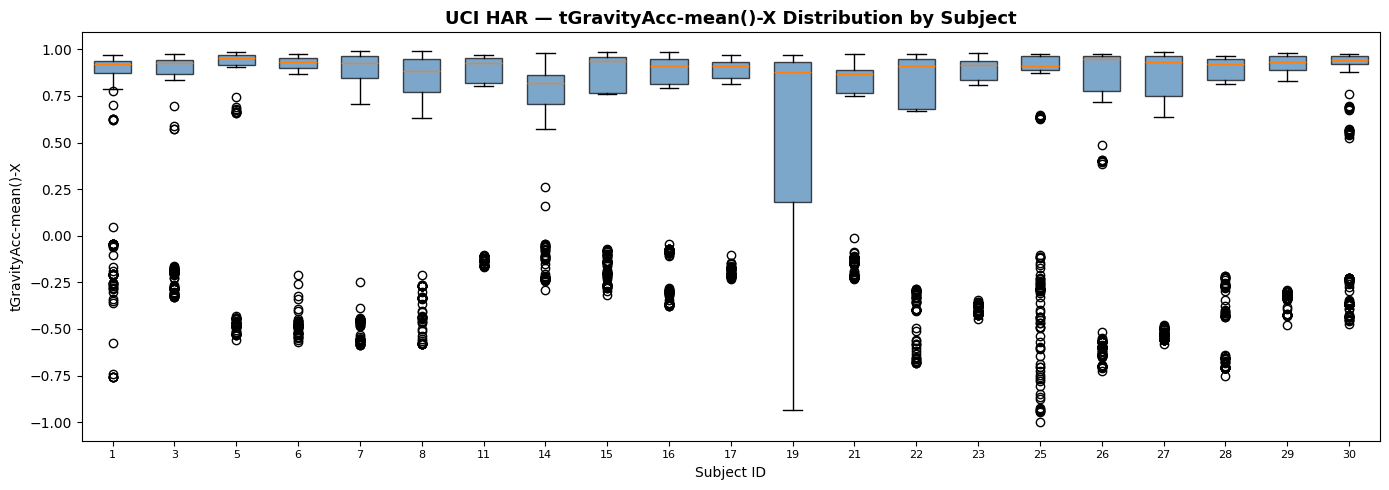

    Subject  1: 347 samples
    Subject  3: 341 samples
    Subject  5: 302 samples
    Subject  6: 325 samples
    Subject  7: 308 samples
    Subject  8: 281 samples
    Subject 11: 316 samples
    Subject 14: 323 samples
    Subject 15: 328 samples
    Subject 16: 366 samples
    Subject 17: 368 samples
    Subject 19: 360 samples
    Subject 21: 408 samples
    Subject 22: 321 samples
    Subject 23: 372 samples
    Subject 25: 409 samples
    Subject 26: 392 samples
    Subject 27: 376 samples
    Subject 28: 382 samples
    Subject 29: 344 samples
    Subject 30: 383 samples


In [9]:
# Step 8: Subject variability — how consistent are features across subjects?
print("=" * 60)
print("[8/9] SUBJECT VARIABILITY")
print("=" * 60)

# Per-subject accuracy proxy: how much do feature distributions vary?
unique_subjects = np.unique(subject_train)
print(f"\nTrain subjects: {len(unique_subjects)}")

# Per-subject class distribution
fig, ax = plt.subplots(figsize=(14, 6))
subject_class_counts = np.zeros((len(unique_subjects), 6))
for i, subj in enumerate(unique_subjects):
    mask = subject_train == subj
    for j, label in enumerate(range(1, 7)):
        subject_class_counts[i, j] = (y_train[mask] == label).sum()

bottom = np.zeros(len(unique_subjects))
for j, (name, color) in enumerate(zip(ACTIVITY_NAMES, colors)):
    ax.bar(range(len(unique_subjects)), subject_class_counts[:, j],
           bottom=bottom, label=name, color=color, edgecolor='black', linewidth=0.3)
    bottom += subject_class_counts[:, j]

ax.set_xticks(range(len(unique_subjects)))
ax.set_xticklabels(unique_subjects, fontsize=8)
ax.set_xlabel('Subject ID')
ax.set_ylabel('Sample Count')
ax.set_title('UCI HAR — Samples per Subject (Train Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper right')
plt.tight_layout()
plt.savefig(EDA_DIR / 'subject_variability.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature variance within vs between subjects
# Pick a discriminative feature to illustrate
feat = 'tGravityAcc-mean()-X'
fig, ax = plt.subplots(figsize=(14, 5))
positions = []
data_by_subject = []
for i, subj in enumerate(unique_subjects):
    mask = subject_train == subj
    data_by_subject.append(X_train[mask][feat].values)

bp = ax.boxplot(data_by_subject, positions=range(len(unique_subjects)),
                widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
ax.set_xticks(range(len(unique_subjects)))
ax.set_xticklabels(unique_subjects, fontsize=8)
ax.set_xlabel('Subject ID')
ax.set_ylabel(feat)
ax.set_title(f'UCI HAR — {feat} Distribution by Subject', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR / 'subject_feature_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Total samples per subject
for subj in unique_subjects:
    n = (subject_train == subj).sum()
    print(f"    Subject {subj:2d}: {n} samples")

In [10]:
# Step 9: EDA summary — key findings that drive preprocessing decisions
print("=" * 60)
print("[9/9] EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

print("""
DATASET: UCI HAR (Human Activity Recognition)
    - 10,299 samples (7,352 train / 2,947 test)
    - 561 features (sensor-derived, pre-computed)
    - 6 activity classes (3 dynamic, 3 static)
    - Subject-wise split: 21 train / 9 test (no leakage)

DATA QUALITY:
    - Zero NaNs, zero Infs, zero duplicates
    - All features in [-1, 1] (pre-normalized by UCI)
    - 1 near-zero variance feature (harmless)
    - No cross-set leakage confirmed

CLASS BALANCE:
    - Train imbalance ratio: 1.43x (acceptable, no weighting needed)
    - Test imbalance ratio: 1.28x

FEATURE INSIGHTS:
    - 23.3% of pairs have |r| > 0.7 — heavy redundancy
    - 5.2% of pairs have |r| > 0.9 — near-duplicate features
    - Entropy features are most discriminative (static vs dynamic)
    - Gravity features separate LAYING from SITTING/STANDING

SEPARABILITY:
    - t-SNE shows 6 distinct clusters
    - Static vs dynamic is the primary separation axis
    - SITTING/STANDING overlap expected (similar posture)
    - Subject variability exists but within-class structure holds

PREPROCESSING DECISIONS:
    1. StandardScaler — means are skewed (-0.66 median), stds vary 18x
    2. Keep all 561 features — DNN handles redundancy via learned weights
    3. Labels: convert 1-indexed (1-6) to 0-indexed (0-5) for softmax
    4. Preserve subject-wise train/test split (no re-splitting)
    5. Save as .npy for fast loading in pipelines
""")

[9/9] EDA SUMMARY — KEY FINDINGS

DATASET: UCI HAR (Human Activity Recognition)
    - 10,299 samples (7,352 train / 2,947 test)
    - 561 features (sensor-derived, pre-computed)
    - 6 activity classes (3 dynamic, 3 static)
    - Subject-wise split: 21 train / 9 test (no leakage)

DATA QUALITY:
    - Zero NaNs, zero Infs, zero duplicates
    - All features in [-1, 1] (pre-normalized by UCI)
    - 1 near-zero variance feature (harmless)
    - No cross-set leakage confirmed

CLASS BALANCE:
    - Train imbalance ratio: 1.43x (acceptable, no weighting needed)
    - Test imbalance ratio: 1.28x

FEATURE INSIGHTS:
    - 23.3% of pairs have |r| > 0.7 — heavy redundancy
    - 5.2% of pairs have |r| > 0.9 — near-duplicate features
    - Entropy features are most discriminative (static vs dynamic)
    - Gravity features separate LAYING from SITTING/STANDING

SEPARABILITY:
    - t-SNE shows 6 distinct clusters
    - Static vs dynamic is the primary separation axis
    - SITTING/STANDING overlap e